# Filtro pasa bajos


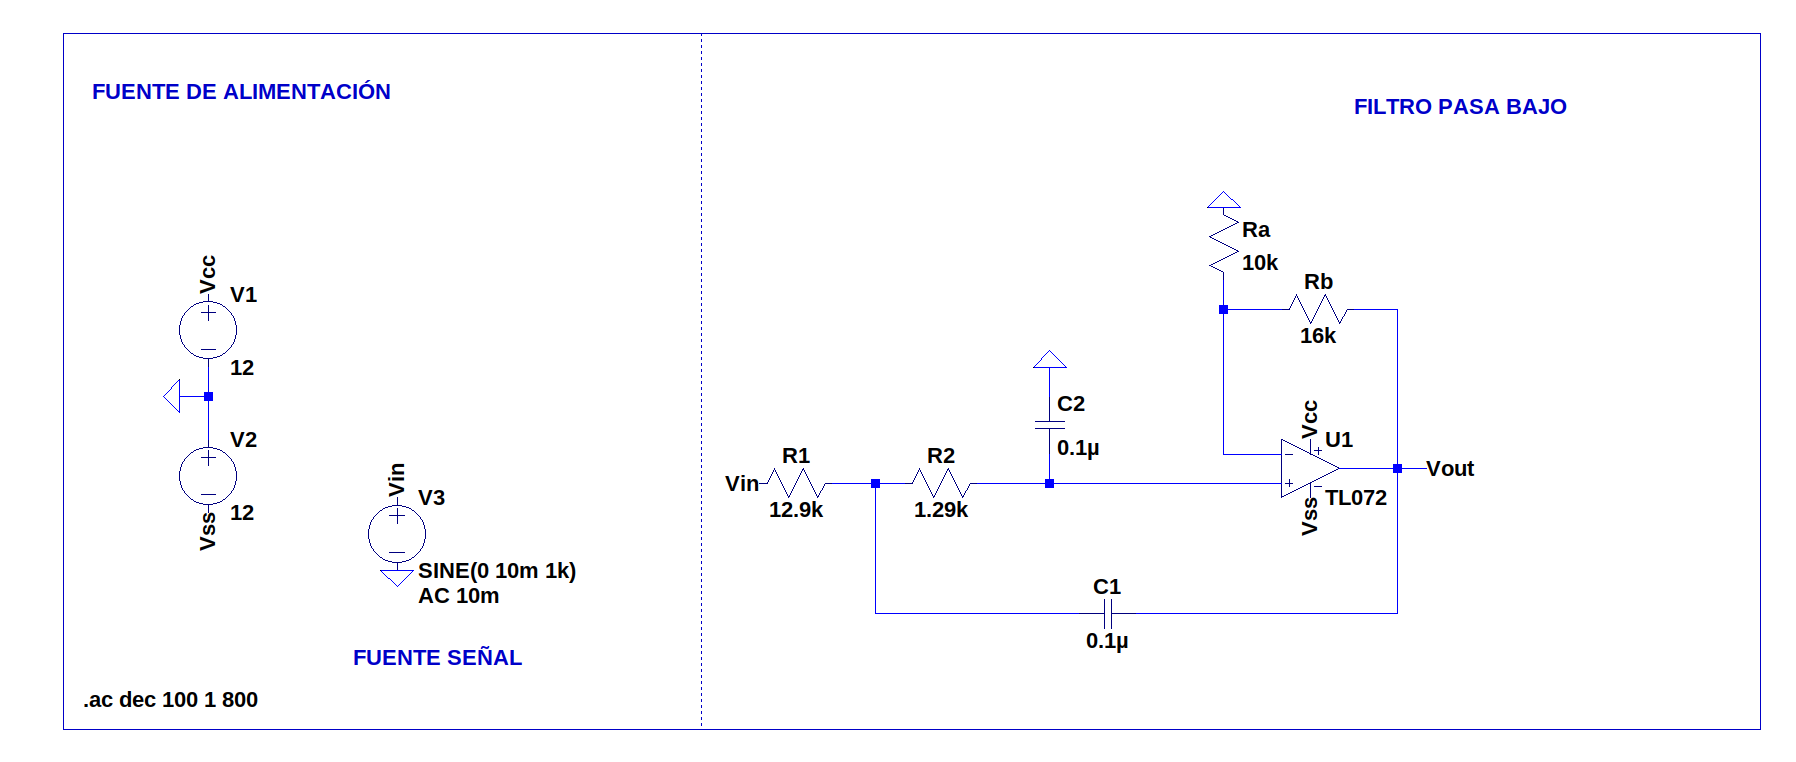

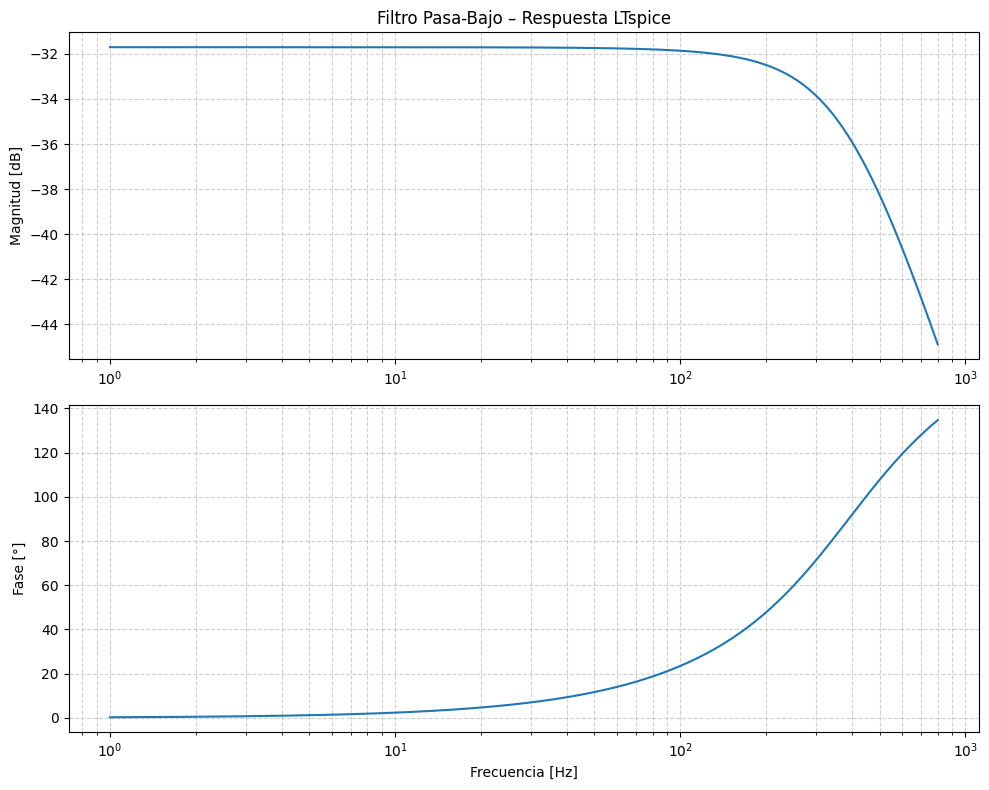

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
#  Lectura del archivo exportado desde LTspice
#  Formato:  Freq   Re,Im
# ======================================================

def load_ltspice_complex(filename):
    freq = []
    re_v = []
    im_v = []

    with open(filename, "r") as f:
        next(f)  # saltear encabezado (Freq.   V(vout))
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            # Frecuencia
            f_val = float(parts[0])

            # Segundo campo: "Re,Im"
            comp = parts[1]
            re_str, im_str = comp.split(',')
            re_val = float(re_str)
            im_val = float(im_str)

            freq.append(f_val)
            re_v.append(re_val)
            im_v.append(im_val)

    freq = np.array(freq)
    re_v = np.array(re_v)
    im_v = np.array(im_v)

    # Magnitud y fase
    v_c = re_v + 1j * im_v
    mag_db = 20*np.log10(np.abs(v_c))
    phase_deg = np.angle(v_c, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
#  Graficar bode pasabajo
# ======================================================

filename = "filtro_pb.txt"   # <-- Cambiar si tu archivo tiene otro nombre

freq, mag_db, phase_deg = load_ltspice_complex(filename)

plt.figure(figsize=(10,8))

# ---------------------------------------
# Magnitud
# ---------------------------------------
plt.subplot(2,1,1)
plt.semilogx(freq, mag_db, label="Pasa-Bajo (LTspice)", color="tab:blue")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Magnitud [dB]")
plt.title("Filtro Pasa-Bajo – Respuesta LTspice")

# ---------------------------------------
# Fase
# ---------------------------------------
plt.subplot(2,1,2)
plt.semilogx(freq, phase_deg, color="tab:blue")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Fase [°]")
plt.xlabel("Frecuencia [Hz]")

plt.tight_layout()
plt.show()



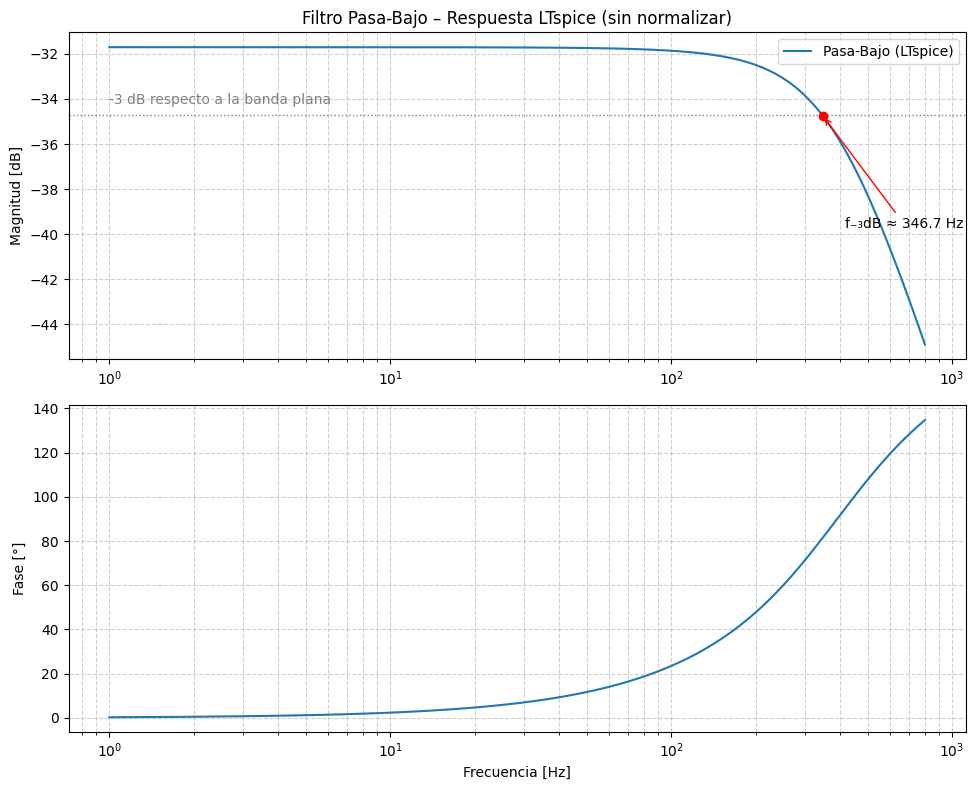

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
#  Lectura del archivo exportado desde LTspice
#  Formato:  Freq   Re,Im
# ======================================================

def load_ltspice_complex(filename):
    freq = []
    re_v = []
    im_v = []

    with open(filename, "r") as f:
        next(f)  # saltear encabezado (Freq.   V(vout))
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            # Frecuencia
            f_val = float(parts[0])

            # Segundo campo: "Re,Im"
            comp = parts[1]
            re_str, im_str = comp.split(',')
            re_val = float(re_str)
            im_val = float(im_str)

            freq.append(f_val)
            re_v.append(re_val)
            im_v.append(im_val)

    freq = np.array(freq)
    re_v = np.array(re_v)
    im_v = np.array(im_v)

    # Magnitud y fase
    v_c = re_v + 1j * im_v
    mag_db = 20*np.log10(np.abs(v_c))
    phase_deg = np.angle(v_c, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
#  Graficar bode pasabajo con caída -3dB (sin normalizar)
# ======================================================

filename = "filtro_pb.txt"   # <-- Cambiar si tu archivo tiene otro nombre

freq, mag_db, phase_deg = load_ltspice_complex(filename)

# Punto -3 dB respecto al valor plano (máximo)
max_gain = np.max(mag_db)
target = max_gain - 3

# Buscar primer cruce hacia abajo
idx_3db = np.where(mag_db <= target)[0][0]
f_3db = freq[idx_3db]
mag_3db = mag_db[idx_3db]

plt.figure(figsize=(10,8))

# ---------------------------------------
# MAGNITUD
# ---------------------------------------
plt.subplot(2,1,1)
plt.semilogx(freq, mag_db, label="Pasa-Bajo (LTspice)", color="tab:blue")

# Línea horizontal del -3 dB (absoluta)
plt.axhline(target, color='gray', linestyle=':', linewidth=1)
plt.text(freq[0], target + 0.5, "-3 dB respecto a la banda plana", color="gray")

# Punto marcado
plt.semilogx(f_3db, mag_3db, 'ro')
plt.annotate(f"f₋₃dB ≈ {f_3db:.1f} Hz",
             xy=(f_3db, mag_3db),
             xytext=(1.2*f_3db, mag_3db - 5),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Magnitud [dB]")
plt.title("Filtro Pasa-Bajo – Respuesta LTspice (sin normalizar)")
plt.legend()

# ---------------------------------------
# FASE
# ---------------------------------------
plt.subplot(2,1,2)
plt.semilogx(freq, phase_deg, color="tab:blue")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Fase [°]")
plt.xlabel("Frecuencia [Hz]")

plt.tight_layout()
plt.show()


In [2]:
import numpy as np

# =====================================================
#  Valores nominales del filtro pasa–bajo real
# =====================================================

R1 = 12.9e3       # ohm
R2 = 1.29e3       # ohm
C1 = 0.1e-6       # farad
C2 = 0.1e-6       # farad

# =====================================================
#  Frecuencia natural aproximada
#  f0 = 1 / (2π * sqrt(R1 R2 C1 C2))
# =====================================================

def f0(R1, R2, C1, C2):
    w0 = 1 / np.sqrt(R1 * R2 * C1 * C2)
    return w0 / (2 * np.pi)


# =====================================================
#  Cálculo nominal y variación del 10% en C1
# =====================================================

f0_nom = f0(R1, R2, C1, C2)
f0_C1_p10 = f0(R1, R2, 1.10*C1, C2)
f0_C1_m10 = f0(R1, R2, 0.90*C1, C2)

print("f0 nominal      = {:.2f} Hz".format(f0_nom))
print("C1 +10%  --> f0 = {:.2f} Hz".format(f0_C1_p10))
print("C1 -10%  --> f0 = {:.2f} Hz".format(f0_C1_m10))


# =====================================================
#  Sensibilidad teórica S = -1/2
#  Validación numérica
# =====================================================

delta_C1 = 0.10  # 10%
pred_teorica = ( -0.5 * delta_C1 ) * f0_nom

print("\nDesplazamiento teórico esperado (S = -1/2):")
print("Δf0 ≈ {:.2f} Hz (aprox.)".format(pred_teorica))

print("\nComprobación con simulación:")
print("Δf0 (+10%) = {:.2f} Hz".format(f0_C1_p10 - f0_nom))
print("Δf0 (−10%) = {:.2f} Hz".format(f0_C1_m10 - f0_nom))


f0 nominal      = 390.15 Hz
C1 +10%  --> f0 = 371.99 Hz
C1 -10%  --> f0 = 411.25 Hz

Desplazamiento teórico esperado (S = -1/2):
Δf0 ≈ -19.51 Hz (aprox.)

Comprobación con simulación:
Δf0 (+10%) = -18.16 Hz
Δf0 (−10%) = 21.10 Hz


Corridas encontradas:
   Step Information: C1val=90n  (Run: 1/3)
   Step Information: C1val=100n  (Run: 2/3)
   Step Information: C1val=110n  (Run: 3/3)
C1 = 0.9·C1_nom  -> fc ≈ 467.7 Hz,  |H| ≈ -34.13 dB
C1 nominal      -> fc ≈ 346.7 Hz, |H| ≈ -34.75 dB
C1 = 1.1·C1_nom -> fc ≈ 239.9 Hz, |H| ≈ -34.68 dB


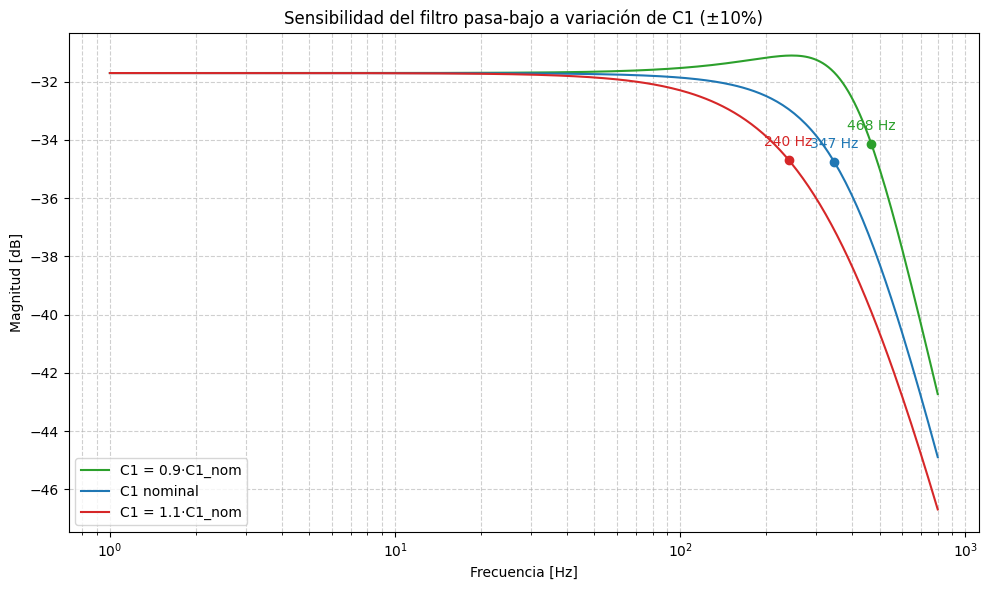

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def load_ltspice_step_runs(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    idx = 1  # saltar "Freq.   V(vout)"
    freq = None
    mags_db = []
    step_info = []

    while idx < len(lines):
        line = lines[idx].strip()

        if line.startswith("Step Information"):
            info = line
            step_info.append(info)
            idx += 1

            freq_run = []
            re_run = []
            im_run = []

            while idx < len(lines):
                l = lines[idx].strip()
                if not l:
                    idx += 1
                    continue
                if l.startswith("Step Information"):
                    break

                parts = l.split()
                if len(parts) < 2:
                    idx += 1
                    continue

                f_val = float(parts[0])
                re_str, im_str = parts[1].split(',')
                re_val = float(re_str)
                im_val = float(im_str)

                freq_run.append(f_val)
                re_run.append(re_val)
                im_run.append(im_val)

                idx += 1

            freq_run = np.array(freq_run)
            v_c = np.array(re_run) + 1j*np.array(im_run)
            mag_db_run = 20*np.log10(np.abs(v_c))

            if freq is None:
                freq = freq_run

            mags_db.append(mag_db_run)
        else:
            idx += 1

    return freq, mags_db, step_info


def cutoff_point(freq, mag_db, delta_db=3):
    """
    Devuelve (f_c, mag_c) donde la magnitud está a delta_db dB
    por debajo del máximo de la curva.
    """
    mag_max = np.max(mag_db)
    target = mag_max - delta_db
    idx = np.argmin(np.abs(mag_db - target))
    return freq[idx], mag_db[idx]


# =======================
#  USO PARA C1 (LP)
# =======================

filename = "filtro_pb_c1val.txt"   # tu archivo exportado

freq, mags_db, step_info = load_ltspice_step_runs(filename)
print("Corridas encontradas:")
for s in step_info:
    print("  ", s)

mag_90n, mag_100n, mag_110n = mags_db  # asumiendo orden 90n,100n,110n

# Frecuencias de corte (-3 dB respecto al máximo de cada curva)
fc_90, mc_90   = cutoff_point(freq, mag_90n)
fc_100, mc_100 = cutoff_point(freq, mag_100n)
fc_110, mc_110 = cutoff_point(freq, mag_110n)

print(f"C1 = 0.9·C1_nom  -> fc ≈ {fc_90:.1f} Hz,  |H| ≈ {mc_90:.2f} dB")
print(f"C1 nominal      -> fc ≈ {fc_100:.1f} Hz, |H| ≈ {mc_100:.2f} dB")
print(f"C1 = 1.1·C1_nom -> fc ≈ {fc_110:.1f} Hz, |H| ≈ {mc_110:.2f} dB")

plt.figure(figsize=(10,6))

# Curvas
plt.semilogx(freq, mag_90n,  label="C1 = 0.9·C1_nom", color="tab:green")
plt.semilogx(freq, mag_100n, label="C1 nominal",      color="tab:blue")
plt.semilogx(freq, mag_110n, label="C1 = 1.1·C1_nom", color="tab:red")

# Marcadores de -3 dB
plt.semilogx(fc_90,  mc_90,  'o', color="tab:green")
plt.semilogx(fc_100, mc_100, 'o', color="tab:blue")
plt.semilogx(fc_110, mc_110, 'o', color="tab:red")

# Opcional: anotaciones
plt.annotate(f"{fc_90:.0f} Hz",  (fc_90,  mc_90),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:green")
plt.annotate(f"{fc_100:.0f} Hz", (fc_100, mc_100),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:blue")
plt.annotate(f"{fc_110:.0f} Hz", (fc_110, mc_110),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:red")

plt.grid(which="both", ls='--', alpha=0.6)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Sensibilidad del filtro pasa-bajo a variación de C1 (±10%)")
plt.legend()
plt.tight_layout()
plt.show()


Corridas encontradas:
   Step Information: R1val=11.61K  (Run: 1/3)
   Step Information: R1val=12.9K  (Run: 2/3)
   Step Information: R1val=14.19K  (Run: 3/3)
R1 = 0.9·R1_nom  -> fc ≈ 398.1 Hz,  |H| ≈ -34.75 dB
R1 nominal      -> fc ≈ 346.7 Hz, |H| ≈ -34.75 dB
R1 = 1.1·R1_nom -> fc ≈ 302.0 Hz, |H| ≈ -34.70 dB


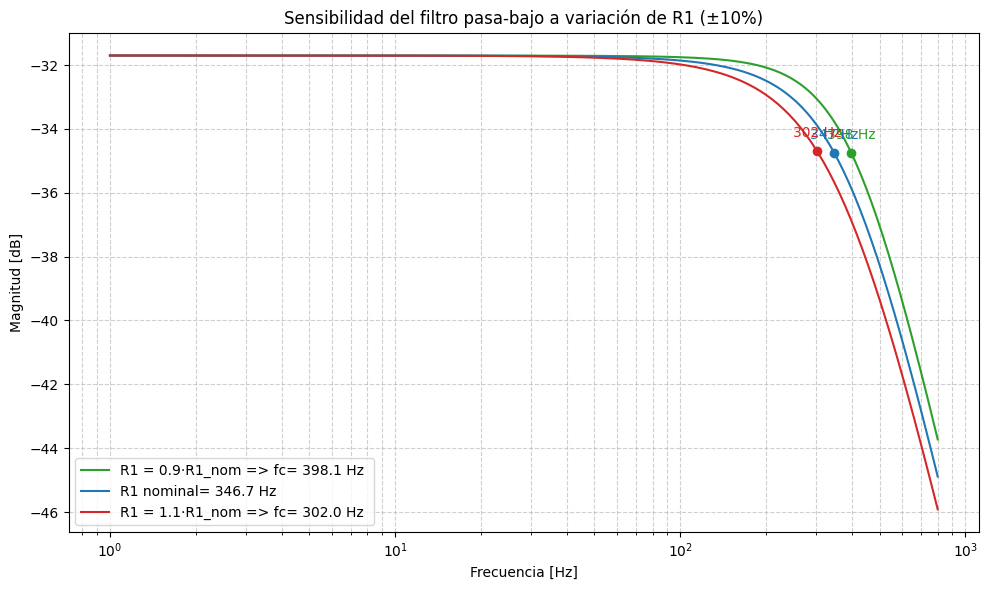

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def load_ltspice_step_runs(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    idx = 1  # saltar "Freq.   V(vout)"
    freq = None
    mags_db = []
    step_info = []

    while idx < len(lines):
        line = lines[idx].strip()

        if line.startswith("Step Information"):
            info = line
            step_info.append(info)
            idx += 1

            freq_run = []
            re_run = []
            im_run = []

            while idx < len(lines):
                l = lines[idx].strip()
                if not l:
                    idx += 1
                    continue
                if l.startswith("Step Information"):
                    break

                parts = l.split()
                if len(parts) < 2:
                    idx += 1
                    continue

                f_val = float(parts[0])
                re_str, im_str = parts[1].split(',')
                re_val = float(re_str)
                im_val = float(im_str)

                freq_run.append(f_val)
                re_run.append(re_val)
                im_run.append(im_val)

                idx += 1

            freq_run = np.array(freq_run)
            v_c = np.array(re_run) + 1j*np.array(im_run)
            mag_db_run = 20*np.log10(np.abs(v_c))

            if freq is None:
                freq = freq_run

            mags_db.append(mag_db_run)
        else:
            idx += 1

    return freq, mags_db, step_info


def cutoff_point(freq, mag_db, delta_db=3):
    """
    Devuelve (f_c, mag_c) donde la magnitud está a delta_db dB
    por debajo del máximo de la curva.
    """
    mag_max = np.max(mag_db)
    target = mag_max - delta_db
    idx = np.argmin(np.abs(mag_db - target))
    return freq[idx], mag_db[idx]


# =======================
#  USO PARA C1 (LP)
# =======================

filename = "filtro_pb_r1val.txt"   # tu archivo exportado

freq, mags_db, step_info = load_ltspice_step_runs(filename)
print("Corridas encontradas:")
for s in step_info:
    print("  ", s)

mag_90n, mag_100n, mag_110n = mags_db  # asumiendo orden 90n,100n,110n

# Frecuencias de corte (-3 dB respecto al máximo de cada curva)
fc_90, mc_90   = cutoff_point(freq, mag_90n)
fc_100, mc_100 = cutoff_point(freq, mag_100n)
fc_110, mc_110 = cutoff_point(freq, mag_110n)

print(f"R1 = 0.9·R1_nom  -> fc ≈ {fc_90:.1f} Hz,  |H| ≈ {mc_90:.2f} dB")
print(f"R1 nominal      -> fc ≈ {fc_100:.1f} Hz, |H| ≈ {mc_100:.2f} dB")
print(f"R1 = 1.1·R1_nom -> fc ≈ {fc_110:.1f} Hz, |H| ≈ {mc_110:.2f} dB")

plt.figure(figsize=(10,6))

# Curvas
plt.semilogx(freq, mag_90n,  label=f"R1 = 0.9·R1_nom => fc= {fc_90:.1f} Hz ", color="tab:green")
plt.semilogx(freq, mag_100n, label=f"R1 nominal= {fc_100:.1f} Hz",      color="tab:blue")
plt.semilogx(freq, mag_110n, label=f"R1 = 1.1·R1_nom => fc= {fc_110:.1f} Hz", color="tab:red")

# Marcadores de -3 dB
plt.semilogx(fc_90,  mc_90,  'o', color="tab:green")
plt.semilogx(fc_100, mc_100, 'o', color="tab:blue")
plt.semilogx(fc_110, mc_110, 'o', color="tab:red")

# Opcional: anotaciones
plt.annotate(f"{fc_90:.0f} Hz",  (fc_90,  mc_90),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:green")
plt.annotate(f"{fc_100:.0f} Hz", (fc_100, mc_100),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:blue")
plt.annotate(f"{fc_110:.0f} Hz", (fc_110, mc_110),
             textcoords="offset points", xytext=(0,10), ha='center', color="tab:red")

plt.grid(which="both", ls='--', alpha=0.6)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Sensibilidad del filtro pasa-bajo a variación de R1 (±10%)")
plt.legend()
plt.tight_layout()
plt.show()


## Mediciones


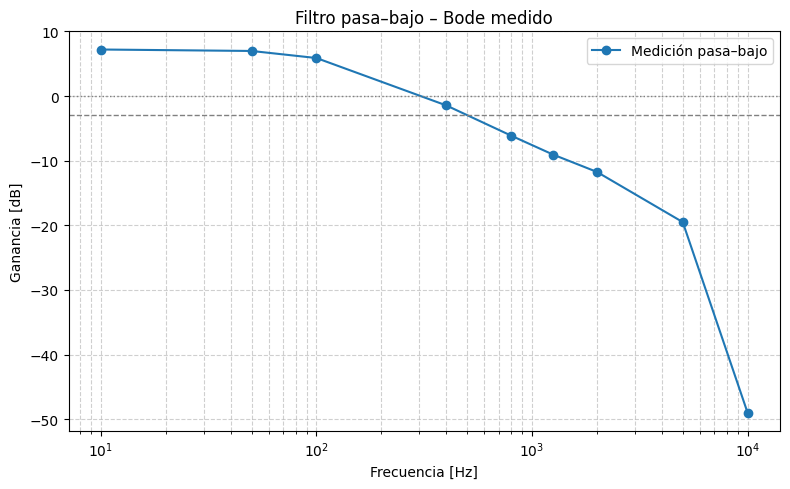

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Datos medidos pasa–bajo
# ==========================
freq = np.array([10, 50, 100, 400, 800, 1250, 2000, 5000, 10000], dtype=float)  # Hz
vout = np.array([0.78, 0.76, 0.67, 0.288, 0.168, 0.12, 0.088, 0.036, 0.0012])   # V
vin = 0.34  # V (amplitud de entrada medida)

# Ganancia y ganancia en dB
gain = vout / vin
gain_db = 20 * np.log10(gain)

# ==========================
# Gráfico de Bode (módulo)
# ==========================
plt.figure(figsize=(8,5))

plt.semilogx(freq, gain_db, 'o-', label='Medición pasa–bajo')
plt.axhline(0, color='gray', linestyle=':', linewidth=1)        # 0 dB (ganancia unitaria)
plt.axhline(-3, color='gray', linestyle='--', linewidth=1)      # línea de -3 dB

plt.grid(which='both', ls='--', alpha=0.6)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Ganancia [dB]')
plt.title('Filtro pasa–bajo – Bode medido')
plt.legend()
plt.tight_layout()
plt.show()


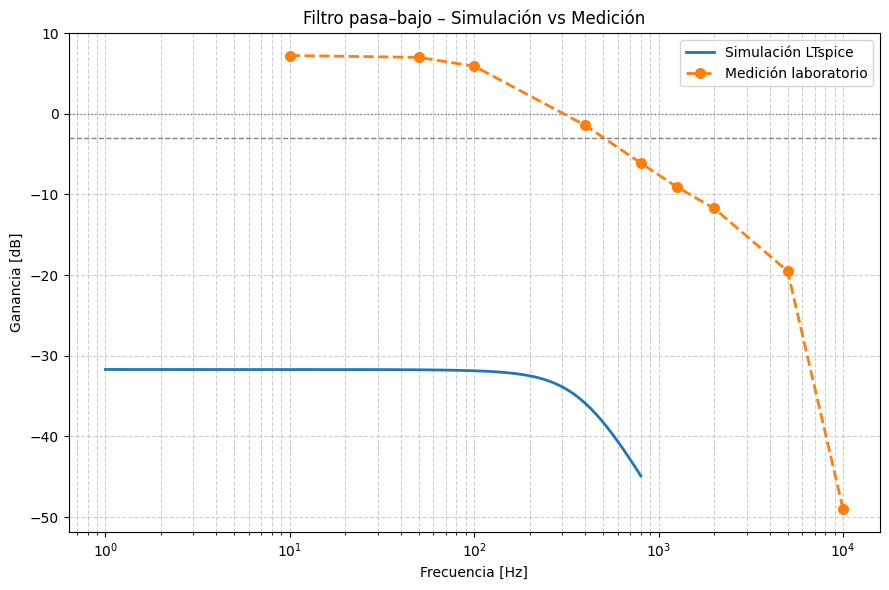

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
#  Función para cargar datos complejos desde LTspice
# ======================================================
def load_ltspice_complex(filename):
    freq = []
    re_v = []
    im_v = []

    with open(filename, "r") as f:
        next(f)  # saltar encabezado (Freq. V(vout))
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            f_val = float(parts[0])
            comp = parts[1]
            re_str, im_str = comp.split(',')
            re_val = float(re_str)
            im_val = float(im_str)

            freq.append(f_val)
            re_v.append(re_val)
            im_v.append(im_val)

    freq = np.array(freq, dtype=float)
    v_c = np.array(re_v) + 1j*np.array(im_v)

    mag_db = 20*np.log10(np.abs(v_c))
    phase_deg = np.angle(v_c, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
#  1) Datos medidos en laboratorio
# ======================================================
freq_meas = np.array([10, 50, 100, 400, 800, 1250, 2000, 5000, 10000], dtype=float)
vout = np.array([0.78, 0.76, 0.67, 0.288, 0.168, 0.12, 0.088, 0.036, 0.0012])
vin = 0.34

gain = vout / vin
gain_db = 20*np.log10(gain)


# ======================================================
#  2) Datos de simulación LTspice
# ======================================================
f_sim, mag_sim_db, phase_sim = load_ltspice_complex("filtro_pb.txt")


# ======================================================
#  3) GRÁFICO SUPERPUESTO
# ======================================================
plt.figure(figsize=(9,6))

# --- Curva LTspice ---
plt.semilogx(f_sim, mag_sim_db, '-', linewidth=2, color='tab:blue', 
             label="Simulación LTspice")

# --- Curva medida ---
plt.semilogx(freq_meas, gain_db, 'o--', markersize=7, linewidth=2,
             color='tab:orange', label="Medición laboratorio")

# Líneas de referencia
plt.axhline(-3, color='gray', linestyle='--', linewidth=1)
plt.axhline(0, color='gray', linestyle=':', linewidth=1)

plt.grid(True, which='both', ls='--', alpha=0.6)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Filtro pasa–bajo – Simulación vs Medición")
plt.legend()
plt.tight_layout()
plt.show()
